In [37]:
from pathlib import Path
from datetime import datetime, timedelta
import time

import requests
import numpy as np
import pandas as pd
import xarray as xr
import rioxarray as rxr

In [38]:
lon_min

-109

In [39]:
#https://journals.ametsoc.org/view/journals/bams/101/12/BAMS-D-19-0272.1.xml
#reference for boundary box

lat_min, lat_max = 45, 49
lon_min, lon_max = -109, -100

year = 2017
scale = "02wk"
etref = "ETrs"

download_dir = Path(f"data/raw/eddi/{year}_{scale}")
download_dir.mkdir(parents=True, exist_ok=True)

print(download_dir.resolve())

/data/keeling/a/marygan2/Capstone/Semester2/2017/data/raw/eddi/2017_02wk


In [40]:
def daterange(start_date, end_date):
    current = start_date
    while current <= end_date:
        yield current
        current += timedelta(days=1)

def build_eddi_url(date_obj, scale="02wk", etref="ETrs"):
    ymd = date_obj.strftime("%Y%m%d")
    year = date_obj.strftime("%Y")
    fname = f"EDDI_{etref}_{scale}_{ymd}.asc"
    url = f"https://downloads.psl.noaa.gov/Projects/EDDI/CONUS_archive/data/{year}/{fname}"
    return url, fname

def download_file(url, out_path, timeout=60):
    r = requests.get(url, stream=True, timeout=timeout)
    if r.status_code != 200:
        return r.status_code, False

    with open(out_path, "wb") as f:
        for chunk in r.iter_content(chunk_size=8192):
            if chunk:
                f.write(chunk)
    return r.status_code, True

def open_and_clip_ascii(path, lon_min, lat_min, lon_max, lat_max):
    da = rxr.open_rasterio(path, masked=True).squeeze()

    # Assign CRS manually
    da = da.rio.write_crs("EPSG:4326")

    # Clip to region
    da = da.rio.clip_box(
        minx=lon_min,
        miny=lat_min,
        maxx=lon_max,
        maxy=lat_max
    )

    # Rename dimensions for easier xarray work
    da = da.rename({"x": "lon", "y": "lat"})
    return da

In [41]:
start = datetime(2017, 1, 1)
end   = datetime(2017, 12, 31)

download_log = []

for dt in daterange(start, end):
    url, fname = build_eddi_url(dt, scale=scale, etref=etref)
    out_path = download_dir / fname

    if out_path.exists():
        download_log.append({
            "date": dt.strftime("%Y-%m-%d"),
            "filename": fname,
            "status_code": 200,
            "downloaded": False,
            "exists_local": True
        })
        continue

    try:
        status_code, ok = download_file(url, out_path)
        download_log.append({
            "date": dt.strftime("%Y-%m-%d"),
            "filename": fname,
            "status_code": status_code,
            "downloaded": ok,
            "exists_local": out_path.exists()
        })
    except Exception as e:
        download_log.append({
            "date": dt.strftime("%Y-%m-%d"),
            "filename": fname,
            "status_code": None,
            "downloaded": False,
            "exists_local": False,
            "error": str(e)
        })

    time.sleep(0.1)  # small pause to be polite to server

download_df = pd.DataFrame(download_log)
download_df.head()

,date,filename,status_code,downloaded,exists_local
0,2017-01-01,EDDI_ETrs_02wk_20170101.asc,200,True,True
1,2017-01-02,EDDI_ETrs_02wk_20170102.asc,200,True,True
2,2017-01-03,EDDI_ETrs_02wk_20170103.asc,200,True,True
3,2017-01-04,EDDI_ETrs_02wk_20170104.asc,200,True,True
4,2017-01-05,EDDI_ETrs_02wk_20170105.asc,200,True,True


In [42]:
print(download_df["status_code"].value_counts(dropna=False))
print(f"\nFiles on disk: {len(list(download_dir.glob('*.asc')))}")

status_code
200    365
Name: count, dtype: int64

Files on disk: 365


In [43]:
files = sorted(download_dir.glob("*.asc"))
print(f"Number of files to process: {len(files)}")

data_arrays = []

for f in files:
    try:
        da = open_and_clip_ascii(
            f,
            lon_min=lon_min,
            lat_min=lat_min,
            lon_max=lon_max,
            lat_max=lat_max
        )

        # Parse date from filename
        # Example: EDDI_ETrs_02wk_20170101.asc
        ymd = f.stem.split("_")[-1]
        dt = pd.to_datetime(ymd, format="%Y%m%d")

        # Add time dimension
        da = da.expand_dims(time=[dt])

        data_arrays.append(da)

    except Exception as e:
        print(f"Failed on {f.name}: {e}")

Number of files to process: 365


In [44]:
eddi_02wk = xr.concat(data_arrays, dim="time").sortby("time")
eddi_02wk.name = "EDDI_02wk"

eddi_02wk

<xarray.DataArray 'EDDI_02wk' (time: 365, lat: 32, lon: 72)> Size: 3MB
array([[[ 2.0279193e-01,  2.0279193e-01,  2.7182949e-01, ...,
          4.1437924e-01,  6.4681131e-01,  6.4681131e-01],
        [ 2.0279193e-01,  2.0279193e-01,  2.7182949e-01, ...,
          4.1437924e-01,  4.8878670e-01,  6.4681131e-01],
        [ 2.0279193e-01,  2.0279193e-01,  2.7182949e-01, ...,
          2.0279193e-01,  3.4222102e-01,  4.1437924e-01],
        ...,
        [ 1.3474596e-01,  1.3474596e-01,  1.3474596e-01, ...,
          3.4222102e-01,  3.4222102e-01,  3.4222102e-01],
        [ 1.3474596e-01,  1.3474596e-01,  1.3474596e-01, ...,
          3.4222102e-01,  4.8878670e-01,  4.8878670e-01],
        [ 2.0279193e-01,  1.3474596e-01,  2.0279193e-01, ...,
          4.8878670e-01,  4.8878670e-01,  4.8878670e-01]],

       [[ 2.7182949e-01,  2.7182949e-01,  3.4222102e-01, ...,
          5.6602407e-01,  7.3206991e-01,  7.3206991e-01],
        [ 2.7182949e-01,  2.7182949e-01,  3.4222102e-01, ...,
          4.8878670e-01,  7.3206991e-01,  8.2302076e-01],
        [ 2.7182949e-01,  2.7182949e-01,  3.4222102e-01, ...,
          3.4222102e-01,  4.1437924e-01,  5.6602407e-01],
...
          1.0294995e+00,  1.1512493e+00,  1.1512493e+00],
        [-1.4648143e+00, -1.4648143e+00, -1.4648143e+00, ...,
          1.1512493e+00,  1.1512493e+00,  1.0294995e+00],
        [-1.2914112e+00, -1.4648143e+00, -1.4648143e+00, ...,
          1.1512493e+00,  1.1512493e+00,  1.1512493e+00]],

       [[-7.3119175e-01, -7.3119175e-01, -5.6523561e-01, ...,
          1.3474596e-01,  3.3473969e-04,  3.3473969e-04],
        [-7.3119175e-01, -7.3119175e-01, -5.6523561e-01, ...,
          2.0279193e-01,  1.3474596e-01,  1.3474596e-01],
        [-6.4598334e-01, -5.6523561e-01, -4.8802972e-01, ...,
          3.4222102e-01,  3.4222102e-01,  3.4222102e-01],
        ...,
        [-1.6985633e+00, -1.6985633e+00, -1.6985633e+00, ...,
          1.0294995e+00,  1.0294995e+00,  1.0294995e+00],
        [-1.4648143e+00, -1.6985633e+00, -1.6985633e+00, ...,
          9.2134905e-01,  9.2134905e-01,  9.2134905e-01],
        [-1.6985633e+00, -1.6985633e+00, -1.6985633e+00, ...,
          1.0294995e+00,  1.0294995e+00,  1.0294995e+00]]],
      shape=(365, 32, 72), dtype=float32)
Coordinates:
  * time         (time) datetime64[ns] 3kB 2017-01-01 2017-01-02 ... 2017-12-31
    band         int64 8B 1
  * lon          (lon) float64 576B -108.9 -108.8 -108.7 ... -100.2 -100.1
  * lat          (lat) float64 256B 48.94 48.81 48.69 ... 45.31 45.19 45.06
    spatial_ref  int64 8B 0
Attributes:
    scale_factor:  1.0
    add_offset:    0.0

In [45]:
print(eddi_02wk)
print("\nTime range:")
print(str(eddi_02wk.time.min().values), "to", str(eddi_02wk.time.max().values))

print("\nLat range:")
print(float(eddi_02wk.lat.min().values), "to", float(eddi_02wk.lat.max().values))

print("\nLon range:")
print(float(eddi_02wk.lon.min().values), "to", float(eddi_02wk.lon.max().values))

<xarray.DataArray 'EDDI_02wk' (time: 365, lat: 32, lon: 72)> Size: 3MB
array([[[ 2.0279193e-01,  2.0279193e-01,  2.7182949e-01, ...,
          4.1437924e-01,  6.4681131e-01,  6.4681131e-01],
        [ 2.0279193e-01,  2.0279193e-01,  2.7182949e-01, ...,
          4.1437924e-01,  4.8878670e-01,  6.4681131e-01],
        [ 2.0279193e-01,  2.0279193e-01,  2.7182949e-01, ...,
          2.0279193e-01,  3.4222102e-01,  4.1437924e-01],
        ...,
        [ 1.3474596e-01,  1.3474596e-01,  1.3474596e-01, ...,
          3.4222102e-01,  3.4222102e-01,  3.4222102e-01],
        [ 1.3474596e-01,  1.3474596e-01,  1.3474596e-01, ...,
          3.4222102e-01,  4.8878670e-01,  4.8878670e-01],
        [ 2.0279193e-01,  1.3474596e-01,  2.0279193e-01, ...,
          4.8878670e-01,  4.8878670e-01,  4.8878670e-01]],

       [[ 2.7182949e-01,  2.7182949e-01,  3.4222102e-01, ...,
          5.6602407e-01,  7.3206991e-01,  7.3206991e-01],
        [ 2.7182949e-01,  2.7182949e-01,  3.4222102e-01, ...,
          4.

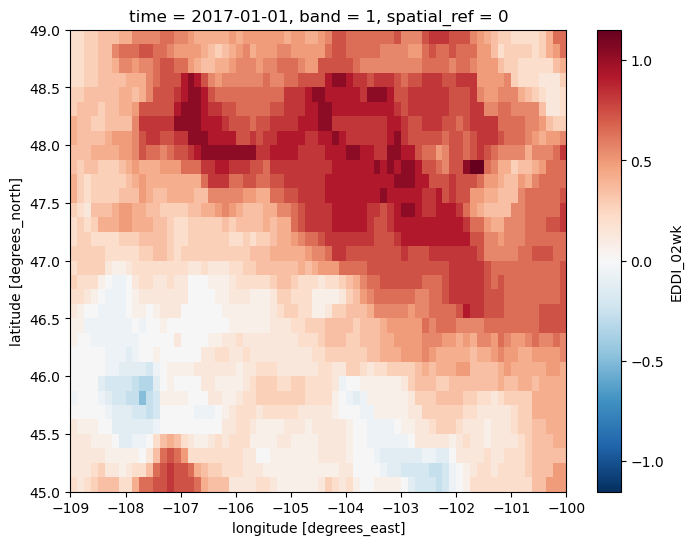

In [46]:
eddi_02wk.isel(time=0).plot(figsize=(8, 6))

In [47]:
output_path = Path("data/intermediate/eddi_02wk_2017_region.nc")
output_path.parent.mkdir(parents=True, exist_ok=True)

eddi_02wk.to_netcdf(output_path)
print(f"Saved to {output_path.resolve()}")

Saved to /data/keeling/a/marygan2/Capstone/Semester2/2017/data/intermediate/eddi_02wk_2017_region.nc


In [48]:
eddi_02wk

<xarray.DataArray 'EDDI_02wk' (time: 365, lat: 32, lon: 72)> Size: 3MB
array([[[ 2.0279193e-01,  2.0279193e-01,  2.7182949e-01, ...,
          4.1437924e-01,  6.4681131e-01,  6.4681131e-01],
        [ 2.0279193e-01,  2.0279193e-01,  2.7182949e-01, ...,
          4.1437924e-01,  4.8878670e-01,  6.4681131e-01],
        [ 2.0279193e-01,  2.0279193e-01,  2.7182949e-01, ...,
          2.0279193e-01,  3.4222102e-01,  4.1437924e-01],
        ...,
        [ 1.3474596e-01,  1.3474596e-01,  1.3474596e-01, ...,
          3.4222102e-01,  3.4222102e-01,  3.4222102e-01],
        [ 1.3474596e-01,  1.3474596e-01,  1.3474596e-01, ...,
          3.4222102e-01,  4.8878670e-01,  4.8878670e-01],
        [ 2.0279193e-01,  1.3474596e-01,  2.0279193e-01, ...,
          4.8878670e-01,  4.8878670e-01,  4.8878670e-01]],

       [[ 2.7182949e-01,  2.7182949e-01,  3.4222102e-01, ...,
          5.6602407e-01,  7.3206991e-01,  7.3206991e-01],
        [ 2.7182949e-01,  2.7182949e-01,  3.4222102e-01, ...,
          4.8878670e-01,  7.3206991e-01,  8.2302076e-01],
        [ 2.7182949e-01,  2.7182949e-01,  3.4222102e-01, ...,
          3.4222102e-01,  4.1437924e-01,  5.6602407e-01],
...
          1.0294995e+00,  1.1512493e+00,  1.1512493e+00],
        [-1.4648143e+00, -1.4648143e+00, -1.4648143e+00, ...,
          1.1512493e+00,  1.1512493e+00,  1.0294995e+00],
        [-1.2914112e+00, -1.4648143e+00, -1.4648143e+00, ...,
          1.1512493e+00,  1.1512493e+00,  1.1512493e+00]],

       [[-7.3119175e-01, -7.3119175e-01, -5.6523561e-01, ...,
          1.3474596e-01,  3.3473969e-04,  3.3473969e-04],
        [-7.3119175e-01, -7.3119175e-01, -5.6523561e-01, ...,
          2.0279193e-01,  1.3474596e-01,  1.3474596e-01],
        [-6.4598334e-01, -5.6523561e-01, -4.8802972e-01, ...,
          3.4222102e-01,  3.4222102e-01,  3.4222102e-01],
        ...,
        [-1.6985633e+00, -1.6985633e+00, -1.6985633e+00, ...,
          1.0294995e+00,  1.0294995e+00,  1.0294995e+00],
        [-1.4648143e+00, -1.6985633e+00, -1.6985633e+00, ...,
          9.2134905e-01,  9.2134905e-01,  9.2134905e-01],
        [-1.6985633e+00, -1.6985633e+00, -1.6985633e+00, ...,
          1.0294995e+00,  1.0294995e+00,  1.0294995e+00]]],
      shape=(365, 32, 72), dtype=float32)
Coordinates:
  * time         (time) datetime64[ns] 3kB 2017-01-01 2017-01-02 ... 2017-12-31
    band         int64 8B 1
  * lon          (lon) float64 576B -108.9 -108.8 -108.7 ... -100.2 -100.1
  * lat          (lat) float64 256B 48.94 48.81 48.69 ... 45.31 45.19 45.06
    spatial_ref  int64 8B 0
Attributes:
    scale_factor:  1.0
    add_offset:    0.0

(array([ 21060.,  29282.,  47959.,  76408., 124760., 133897., 114860.,
         69406.,  79861., 143467.]),
 array([-2.09854484, -1.67822552, -1.2579062 , -0.83758688, -0.41726756,
         0.00305176,  0.42337108,  0.8436904 ,  1.26400971,  1.68432903,
         2.10464835]),
 <BarContainer object of 10 artists>)

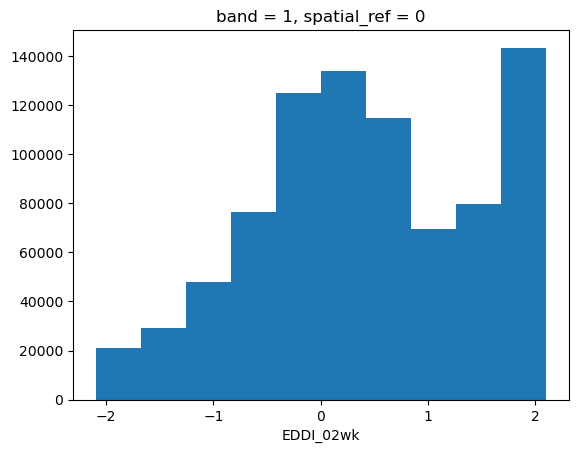

In [49]:
eddi_02wk.plot()